# Data Exploration

Comprehensive EDA for the Amazon ML Challenge entity resolution task.

## Setup

In [4]:
import re
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 4)

DATA_DIR = Path("../../../dataset")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"


In [5]:
# String similarity libs, install via uv/pip if missing:
# uv add python-Levenshtein jellyfish rapidfuzz
try:
    import Levenshtein
    import jellyfish
    HAVE_SIMLIBS = True
except ImportError:
    HAVE_SIMLIBS = False
    print("Levenshtein/jellyfish not installed; run `pip install python-levenshtein jellyfish` and re-run cells in section 7.")


## Load Data & Schema Sanity Checks

Files are tab-separated, so `sep="\t"` is required.

In [6]:
def load_source(path):
    df = pd.read_csv(path, sep="\t", dtype=str, keep_default_na=False, na_values=[""])
    return df

train_s1 = load_source(TRAIN_DIR / "train_source1.tsv")
train_s2 = load_source(TRAIN_DIR / "train_source2.tsv")
train_s3 = load_source(TRAIN_DIR / "train_source3.tsv")
gt = load_source(TRAIN_DIR / "train_ground_truth.tsv")

test_s1 = load_source(TEST_DIR / "test_source1.tsv")
test_s2 = load_source(TEST_DIR / "test_source2.tsv")
test_s3 = load_source(TEST_DIR / "test_source3.tsv")

for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("gt", gt), ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    print(f"{name:10s} shape={df.shape}  columns={list(df.columns)}")


train_s1   shape=(2206821, 4)  columns=['entity_id', 'business_name', 'business_address', 'country']
train_s2   shape=(5034616, 4)  columns=['entity_id', 'business_name', 'business_address', 'country']
train_s3   shape=(5285603, 4)  columns=['entity_id', 'business_name', 'business_address', 'country']
gt         shape=(2206821, 2)  columns=['source1_entity_id', 'matched_entity_ids']
test_s1    shape=(1732544, 4)  columns=['entity_id', 'business_name', 'business_address', 'country']
test_s2    shape=(4887273, 4)  columns=['entity_id', 'business_name', 'business_address', 'country']
test_s3    shape=(5082316, 4)  columns=['entity_id', 'business_name', 'business_address', 'country']


In [7]:
# Sanity check: entity_id prefixes match the file/source they came from
def check_prefix(df, prefix, name):
    bad = df[~df["entity_id"].str.startswith(prefix)]
    print(f"{name}: {len(bad)} rows with unexpected entity_id prefix" +
          (f"; e.g. {bad['entity_id'].head(3).tolist()}" if len(bad) else "; OK"))

check_prefix(train_s1, "S1-", "train_s1")
check_prefix(train_s2, "S2-", "train_s2")
check_prefix(train_s3, "S3-", "train_s3")
check_prefix(test_s1, "S1-", "test_s1")
check_prefix(test_s2, "S2-", "test_s2")
check_prefix(test_s3, "S3-", "test_s3")

# entity_id uniqueness within each file
for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    dupes = df["entity_id"].duplicated().sum()
    print(f"{name}: {dupes} duplicate entity_ids")


train_s1: 0 rows with unexpected entity_id prefix; OK
train_s2: 0 rows with unexpected entity_id prefix; OK
train_s3: 0 rows with unexpected entity_id prefix; OK
test_s1: 0 rows with unexpected entity_id prefix; OK
test_s2: 0 rows with unexpected entity_id prefix; OK
test_s3: 0 rows with unexpected entity_id prefix; OK
train_s1: 0 duplicate entity_ids
train_s2: 0 duplicate entity_ids
train_s3: 0 duplicate entity_ids
test_s1: 0 duplicate entity_ids
test_s2: 0 duplicate entity_ids
test_s3: 0 duplicate entity_ids


## Missing Values & Basic Stats

In [8]:
def missing_report(df, name):
    rep = df.isna().mean().rename(name).to_frame().T
    return rep

pd.concat([
    missing_report(train_s1, "train_s1"),
    missing_report(train_s2, "train_s2"),
    missing_report(train_s3, "train_s3"),
    missing_report(test_s1, "test_s1"),
    missing_report(test_s2, "test_s2"),
    missing_report(test_s3, "test_s3"),
])


,entity_id,business_name,business_address,country
train_s1,0.0,0.0,0.000000,0.0
train_s2,0.0,0.0,0.033561,0.0
train_s3,0.0,0.0,0.033282,0.0
test_s1,0.0,0.0,0.000000,0.0
test_s2,0.0,0.0,0.026479,0.0
test_s3,0.0,0.0,0.026779,0.0


In [9]:
for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3)]:
    print(f"\n--- {name} sample ---")
    display(df.sample(min(3, len(df)), random_state=0))



--- train_s1 sample ---


,entity_id,business_name,business_address,country
1368956,S1-889749447,Jagsakti Foodworks Group,"Gata No 98, Nasirpur, Sambhal Road, Mainather, Sambhal, Moradabad, Uttar Pra...",India
581559,S1-921626517,Traum Peak Logistics P.C.,"82 Rogers Street, Atlanta, GA",US
452732,S1-582122760,Vaibhav Formulations LLP,"15/64 Garden House Elankom Gardens, Vellayambalam, Thiruvananthapuram, Triva...",India



--- train_s2 sample ---


,entity_id,business_name,business_address,country
4771194,S2-567781405,Upper Fresh Mortgage Inc,"148 18ST ST, SN BERNARDINO CITY, CA",US
2215184,S2-178149510,hítechengineering.com,"81, BURTOLLA STREET, KOLKATA, KOLKATA, West Bengal",India
4568136,S2-147956255,Co Mckenzie Be Colombier,"24312 Lakeland Blvd, EUCLID, OH",US



--- train_s3 sample ---


,entity_id,business_name,business_address,country
1390729,S3-92878684,Qutubullapur Group Service,"H.no-8-61, Hyderabad, TG",India
3183781,S3-161601800,Pvt XRW Moulding Ltd,"C/o Venkata Ramana N, Mullavandlakota, Chinnamandem, Cuddapah, AP",India
4904054,S3-656326203,"Chang, Crawford and Williams Cayson","Unit Unit 119, Wisconsin, Pewaukee, 00700 Quinlan Drive",US


## Ground Truth Structure

This is the key distribution for understanding the F_0.5 scoring dynamics; 
singletons matter as much as multi-matches.

In [10]:
gt["matched_list"] = gt["matched_entity_ids"].fillna("").apply(
    lambda s: [x.strip() for x in s.split(",") if x.strip()] if s else []
)
gt["n_matches"] = gt["matched_list"].apply(len)

print(f"Total Source-1 training entities: {len(gt)}")
print(f"Singletons (no match): {(gt['n_matches'] == 0).sum()} "
      f"({(gt['n_matches'] == 0).mean():.1%})")
print(f"Exactly 1 match: {(gt['n_matches'] == 1).sum()} ({(gt['n_matches'] == 1).mean():.1%})")
print(f"2+ matches: {(gt['n_matches'] >= 2).sum()} ({(gt['n_matches'] >= 2).mean():.1%})")
print(f"Max matches for a single entity: {gt['n_matches'].max()}")


Total Source-1 training entities: 2206821
Singletons (no match): 123247 (5.6%)
Exactly 1 match: 119157 (5.4%)
2+ matches: 1964417 (89.0%)
Max matches for a single entity: 11


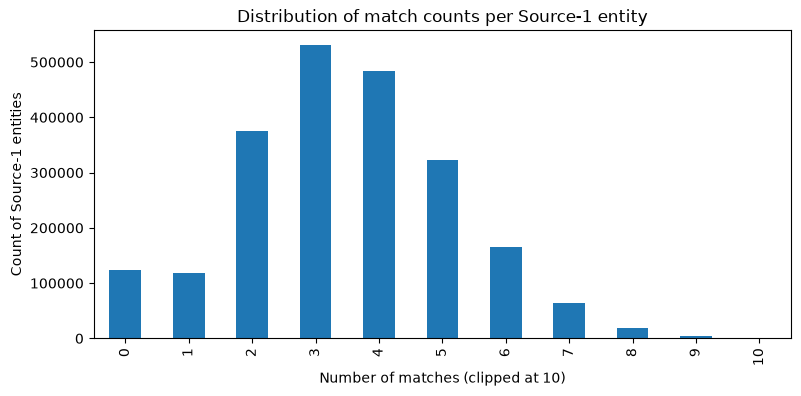

In [11]:
fig, ax = plt.subplots()
gt["n_matches"].clip(upper=10).value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Number of matches (clipped at 10)")
ax.set_ylabel("Count of Source-1 entities")
ax.set_title("Distribution of match counts per Source-1 entity")
plt.show()


In [12]:
# Breakdown of matches by source (S2 vs S3)
def source_breakdown(ids):
    s2 = sum(1 for i in ids if i.startswith("S2-"))
    s3 = sum(1 for i in ids if i.startswith("S3-"))
    return s2, s3

breakdown = gt["matched_list"].apply(source_breakdown)
gt["n_s2_matches"] = breakdown.apply(lambda t: t[0])
gt["n_s3_matches"] = breakdown.apply(lambda t: t[1])

print(f"Total S2 matches: {gt['n_s2_matches'].sum()}  |  Total S3 matches: {gt['n_s3_matches'].sum()}")
print(f"Entities with only S2 matches: {((gt['n_s2_matches']>0) & (gt['n_s3_matches']==0)).sum()}")
print(f"Entities with only S3 matches: {((gt['n_s3_matches']>0) & (gt['n_s2_matches']==0)).sum()}")
print(f"Entities with both: {((gt['n_s2_matches']>0) & (gt['n_s3_matches']>0)).sum()}")


Total S2 matches: 3693619  |  Total S3 matches: 3944746
Entities with only S2 matches: 143029
Entities with only S3 matches: 164498
Entities with both: 1776047


In [13]:
# Fast maps for looking up entity strings across sources
s1_name_map = train_s1.set_index("entity_id")["business_name"].to_dict()
s2_name_map = train_s2.set_index("entity_id")["business_name"].to_dict()
s3_name_map = train_s3.set_index("entity_id")["business_name"].to_dict()

s1_addr_map = train_s1.set_index("entity_id")["business_address"].to_dict()
s2_addr_map = train_s2.set_index("entity_id")["business_address"].to_dict()
s3_addr_map = train_s3.set_index("entity_id")["business_address"].to_dict()

def lookup_name(eid):
    if eid.startswith("S1-"): return s1_name_map.get(eid)
    if eid.startswith("S2-"): return s2_name_map.get(eid)
    if eid.startswith("S3-"): return s3_name_map.get(eid)
    return None

def lookup_addr(eid):
    if eid.startswith("S1-"): return s1_addr_map.get(eid)
    if eid.startswith("S2-"): return s2_addr_map.get(eid)
    if eid.startswith("S3-"): return s3_addr_map.get(eid)
    return None


In [ ]:
# Sanity: every matched id actually exists in the corresponding source file, no self-matches
s2_ids = set(train_s2["entity_id"])
s3_ids = set(train_s3["entity_id"])
s1_ids = set(train_s1["entity_id"])

all_matched = set(x for lst in gt["matched_list"] for x in lst)
bad_ids = [x for x in all_matched if not (
    (x.startswith("S2-") and x in s2_ids) or (x.startswith("S3-") and x in s3_ids)
)]
print(f"Ground-truth matched IDs not found in S2/S3 (or wrong prefix): {len(bad_ids)}")
if bad_ids[:5]:
    print("Examples:", bad_ids[:5])

# every Source-1 entity in gt should exist in train_s1
missing_s1 = set(gt["source1_entity_id"]) - s1_ids
print(f"GT source1_entity_ids missing from train_s1: {len(missing_s1)}")


### Baseline Metric Evaluator (F_0.5 Macro-Average)

Implementation of the macro F_0.5 evaluation metric to test simple baselines.

In [ ]:
def compute_entity_f05(pred_ids, true_ids):
    pred_set, true_set = set(pred_ids), set(true_ids)
    if not pred_set and not true_set:
        return 1.0  # Correct singleton prediction
    if not pred_set and true_set:
        return 0.0  # Missed matches
    if pred_set and not true_set:
        return 0.0  # False merge on singleton
    
    tp = len(pred_set & true_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    if prec + rec == 0:
        return 0.0
    return (1.25 * prec * rec) / (0.25 * prec + rec)

def evaluate_predictions(pred_dict, gt_df):
    scores = []
    for _, row in gt_df.iterrows():
        s1_id = row["source1_entity_id"]
        true_list = row["matched_list"]
        pred_list = pred_dict.get(s1_id, [])
        scores.append(compute_entity_f05(pred_list, true_list))
    return np.mean(scores)

# Baseline 1: Predict Empty / Singletons for all entities
empty_preds = {s1_id: [] for s1_id in gt["source1_entity_id"]}
print(f"Baseline Score (Predict All Singletons): {evaluate_predictions(empty_preds, gt):.4f}")


## Country Distribution; Train vs Test

Confirms France appears only in test, per the problem statement, and checks
for an open-set of country labels (don't assume just {US, India, France}).

In [ ]:
for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    print(f"\n{name} country counts:")
    print(df["country"].value_counts(dropna=False))


In [ ]:
train_countries = set(train_s1["country"]) | set(train_s2["country"]) | set(train_s3["country"])
test_countries  = set(test_s1["country"])  | set(test_s2["country"])  | set(test_s3["country"])

print("Countries in train:", train_countries)
print("Countries in test :", test_countries)
print("Countries in test but NOT train:", test_countries - train_countries)


## Name & Address Length / Token Statistics

In [ ]:
def add_len_stats(df):
    df = df.copy()
    df["name_len"] = df["business_name"].str.len()
    df["name_ntokens"] = df["business_name"].str.split().apply(len)
    df["addr_len"] = df["business_address"].fillna("").str.len()
    df["addr_ntokens"] = df["business_address"].fillna("").str.split().apply(len)
    return df

train_s1_stats = add_len_stats(train_s1)
train_s2_stats = add_len_stats(train_s2)
train_s3_stats = add_len_stats(train_s3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, df in [("S1", train_s1_stats), ("S2", train_s2_stats), ("S3", train_s3_stats)]:
    axes[0].hist(df["name_len"], bins=30, alpha=0.5, label=name)
    axes[1].hist(df["addr_len"], bins=30, alpha=0.5, label=name)
axes[0].set_title("business_name length"); axes[0].legend()
axes[1].set_title("business_address length"); axes[1].legend()
plt.tight_layout(); plt.show()

for name, df in [("S1", train_s1_stats), ("S2", train_s2_stats), ("S3", train_s3_stats)]:
    print(f"{name}: name_len mean={df['name_len'].mean():.1f}  "
          f"addr_len mean={df['addr_len'].mean():.1f}  "
          f"addr missing={df['business_address'].isna().mean():.1%}")


## Script / Language Audit

The dataset mixes scripts (Latin, Devanagari, and possibly others). Character
n-gram similarity and Levenshtein break down across scripts, so we need to
know the actual distribution before deciding whether transliteration
preprocessing / multilingual embeddings are a "nice to have" or a "must have."

This uses Unicode block detection only; no language-ID model, no external
lookups.

In [ ]:
UNICODE_BLOCKS = [
    ("Latin", 0x0000, 0x024F),
    ("Devanagari", 0x0900, 0x097F),
    ("Bengali", 0x0980, 0x09FF),
    ("Gurmukhi", 0x0A00, 0x0A7F),
    ("Gujarati", 0x0A80, 0x0AFF),
    ("Tamil", 0x0B80, 0x0BFF),
    ("Telugu", 0x0C00, 0x0C7F),
    ("Kannada", 0x0C80, 0x0CFF),
    ("Malayalam", 0x0D00, 0x0D7F),
    ("Arabic", 0x0600, 0x06FF),
]

def classify_char(ch):
    cp = ord(ch)
    if ch.isspace() or unicodedata.category(ch).startswith("P"):
        return None  # ignore whitespace/punctuation
    for name, lo, hi in UNICODE_BLOCKS:
        if lo <= cp <= hi:
            return name
    return "Other"

def script_profile(text):
    """Return the dominant script(s) present in a string as a set."""
    if not isinstance(text, str) or not text:
        return set()
    scripts = {classify_char(c) for c in text}
    scripts.discard(None)
    return scripts

def script_mix_label(scripts):
    if not scripts:
        return "empty"
    if len(scripts) == 1:
        return next(iter(scripts))
    return "mixed:" + "+".join(sorted(scripts))

for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    name_scripts = df["business_name"].apply(script_profile).apply(script_mix_label)
    addr_scripts = df["business_address"].fillna("").apply(script_profile).apply(script_mix_label)
    print(f"\n=== {name}; business_name script distribution ===")
    print(name_scripts.value_counts(normalize=True).round(3))
    print(f"--- {name}; business_address script distribution ---")
    print(addr_scripts.value_counts(normalize=True).round(3))


In [ ]:
# Non-Latin fraction per source, the key number for deciding on transliteration
def non_latin_fraction(df, col):
    scripts = df[col].fillna("").apply(script_profile)
    return scripts.apply(lambda s: bool(s - {"Latin"})).mean()

for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    print(f"{name}: business_name non-Latin fraction = {non_latin_fraction(df, 'business_name'):.1%}  "
          f"| business_address non-Latin fraction = {non_latin_fraction(df, 'business_address'):.1%}")


In [ ]:
# Sample some non-Latin-script rows to eyeball actual patterns
def sample_non_latin(df, col, n=8):
    mask = df[col].fillna("").apply(lambda t: bool(script_profile(t) - {"Latin"}))
    return df.loc[mask, [col]].sample(min(n, mask.sum()), random_state=0) if mask.sum() else None

sample_non_latin(train_s2, "business_name")


In [ ]:
# Cross-source check: for matched pairs, do S1/S2/S3 names differ in script?
cross_script_pairs = 0
total_pairs = 0
for _, row in gt.iterrows():
    s1_name = lookup_name(row["source1_entity_id"])
    if s1_name is None:
        continue
    s1_scripts = script_profile(s1_name)
    for mid in row["matched_list"]:
        other_name = lookup_name(mid)
        if other_name is None:
            continue
        other_scripts = script_profile(other_name)
        total_pairs += 1
        if s1_scripts and other_scripts and not (s1_scripts & other_scripts):
            cross_script_pairs += 1

print(f"Matched pairs with completely disjoint scripts between S1 and match: "
      f"{cross_script_pairs}/{total_pairs} ({cross_script_pairs/max(total_pairs,1):.1%})")


## String-Similarity Separability: Positive vs Negative Pairs

Sample true matches (from ground truth) and random non-matches, compute
similarity features, and check how separable the two distributions are.
This tells you directly which features are worth including in the matcher.

In [ ]:
import random
random.seed(0)

def jaccard_tokens(a, b):
    ta, tb = set(str(a).lower().split()), set(str(b).lower().split())
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)

def build_pair_features(name1, name2, addr1, addr2):
    feats = {"name_jaccard": jaccard_tokens(name1, name2),
             "addr_jaccard": jaccard_tokens(addr1, addr2)}
    if HAVE_SIMLIBS:
        feats["name_levenshtein"] = Levenshtein.ratio(str(name1).lower(), str(name2).lower())
        feats["name_jaro_winkler"] = jellyfish.jaro_winkler_similarity(str(name1).lower(), str(name2).lower())
        feats["addr_levenshtein"] = Levenshtein.ratio(str(addr1).lower(), str(addr2).lower())
    return feats

# Positive pairs using fast map lookups
pos_rows = []
for _, row in gt.iterrows():
    s1_id = row["source1_entity_id"]
    s1_name, s1_addr = lookup_name(s1_id), lookup_addr(s1_id)
    if s1_name is None:
        continue
    for mid in row["matched_list"]:
        other_name, other_addr = lookup_name(mid), lookup_addr(mid)
        if other_name is None:
            continue
        pos_rows.append(build_pair_features(s1_name, other_name, s1_addr, other_addr))

pos_df = pd.DataFrame(pos_rows)
pos_df["label"] = 1
print(f"Positive pairs sampled: {len(pos_df)}")


In [ ]:
# Negative pairs: random Source1 x (Source2 or Source3) combos that are NOT in ground truth
matched_set = set()
for _, row in gt.iterrows():
    for mid in row["matched_list"]:
        matched_set.add((row["source1_entity_id"], mid))

s1_sample_ids = train_s1["entity_id"].sample(min(2000, len(train_s1)), random_state=0).tolist()
s2_ids_list = train_s2["entity_id"].tolist()
s3_ids_list = train_s3["entity_id"].tolist()
all_target_ids = s2_ids_list + s3_ids_list

neg_rows = []
n_target = len(pos_df)
tries = 0
while len(neg_rows) < n_target and tries < n_target * 20:
    tries += 1
    s1_id = random.choice(s1_sample_ids)
    other_id = random.choice(all_target_ids)
    if (s1_id, other_id) in matched_set:
        continue
    s1_name, s1_addr = lookup_name(s1_id), lookup_addr(s1_id)
    other_name, other_addr = lookup_name(other_id), lookup_addr(other_id)
    if s1_name is None or other_name is None:
        continue
    neg_rows.append(build_pair_features(s1_name, other_name, s1_addr, other_addr))

neg_df = pd.DataFrame(neg_rows)
neg_df["label"] = 0
print(f"Negative pairs sampled: {len(neg_df)}")

pair_features = pd.concat([pos_df, neg_df], ignore_index=True)
display(pair_features.groupby("label").mean(numeric_only=True))


In [ ]:
feature_cols = [c for c in pair_features.columns if c != "label"]
fig, axes = plt.subplots(1, len(feature_cols), figsize=(4.5 * len(feature_cols), 4))
if len(feature_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, feature_cols):
    ax.hist(pair_features.loc[pair_features.label == 1, col], bins=30, alpha=0.5, label="match", density=True)
    ax.hist(pair_features.loc[pair_features.label == 0, col], bins=30, alpha=0.5, label="no match", density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout(); plt.show()


## Legal-Suffix / Abbreviation Pattern Survey

In [ ]:
SUFFIX_PATTERN = re.compile(
    r"\b(corp|corporation|inc|incorporated|ltd|limited|llc|llp|pvt|private|co|company|"
    r"pty|gmbh|sarl|sas|plc)\b\.?", re.IGNORECASE
)

def extract_suffixes(series):
    matches = series.fillna("").apply(lambda s: SUFFIX_PATTERN.findall(s))
    flat = [m.lower().rstrip(".") for lst in matches for m in lst]
    return Counter(flat)

for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3)]:
    print(f"\n{name} legal-suffix frequency:")
    print(extract_suffixes(df["business_name"]).most_common(15))


## Address Structure Signals

Numeric tokens (street numbers, postal codes) tend to survive across
language/format variation better than text does; worth checking how often
they're present at all.

In [ ]:
NUMERIC_TOKEN = re.compile(r"\b\d{2,}\b")  # 2+ digit numeric tokens (building nos, PINs, etc.)

def has_numeric_token(addr):
    return bool(NUMERIC_TOKEN.search(str(addr))) if pd.notna(addr) else False

for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    frac = df["business_address"].apply(has_numeric_token).mean()
    print(f"{name}: fraction of addresses with a 2+ digit numeric token = {frac:.1%}")


In [ ]:
# Postal-code-like pattern (loose heuristic, country-agnostic, 4-6 digit trailing token)
POSTAL_PATTERN = re.compile(r"\b\d{4,6}\b")

def postal_candidates(addr):
    return POSTAL_PATTERN.findall(str(addr)) if pd.notna(addr) else []

train_s1_postal = train_s1["business_address"].apply(postal_candidates)
print(train_s1_postal.apply(len).value_counts())
train_s1[["business_address"]].assign(postal_candidates=train_s1_postal).sample(5, random_state=1)


## Exact-Match Baseline

A quick floor: how many ground-truth matches are recoverable by exact
normalized-name string match alone? This tells you how much of the score a
trivial baseline already captures, and how much value the ML matcher needs
to add on top.

In [ ]:
def normalize_name(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s

s2_norm_map = {}
for eid, nm in s2_name_map.items():
    s2_norm_map.setdefault(normalize_name(nm), set()).add(eid)
s3_norm_map = {}
for eid, nm in s3_name_map.items():
    s3_norm_map.setdefault(normalize_name(nm), set()).add(eid)

exact_hits, total_pos = 0, 0
exact_preds = {}
for _, row in gt.iterrows():
    s1_id = row["source1_entity_id"]
    s1_name = lookup_name(s1_id)
    if s1_name is None:
        continue
    norm = normalize_name(s1_name)
    candidates = list(s2_norm_map.get(norm, set()) | s3_norm_map.get(norm, set()))
    exact_preds[s1_id] = candidates
    
    truth = set(row["matched_list"])
    if truth:
        total_pos += 1
        if set(candidates) & truth:
            exact_hits += 1

print(f"Source-1 entities with >=1 match recoverable via exact normalized-name match: "
      f"{exact_hits}/{total_pos} ({exact_hits/max(total_pos,1):.1%})")
print(f"Exact Normalized Name Match Macro F_0.5 Score: {evaluate_predictions(exact_preds, gt):.4f}")


## Summary of Findings

Need to fill this in later, but not really needed.

- **Singleton fraction**: `___%`: sets the baseline for "predict nothing" and shows how much precision-discipline the matcher needs.
- **Non-Latin script fraction** (name / address, by source): `___`: shows whether transliteration preprocessing and a multilingual embedding model are required or a minor backstop.
- **Cross-script matched pairs**: `___%`: shows whether character n-gram blocking alone will miss recall on script-crossing pairs.
- **Exact-match baseline recall**: `___%`: the floor your blocking + matcher pipeline must clear.
- **Feature separability** (section 7 plots): which similarity features show the cleanest positive/negative separation: focus on these in the matcher; drop or de-weight features with heavy overlap.
- **Address numeric-token coverage**: `___%`: whether numeric exact-match features are broadly usable or only helpful for a subset of records.
- **France in test only**: confirmed; no French training examples, so validate that whatever normalization/feature pipeline you build doesn't implicitly depend on India/US-specific abbreviation dictionaries.
